<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

<b>ESPECIALIZACIÓN EN CIENCIA DE DATOS E INGELIGENCIA ARTIFICIAL</b>

<strong>Fundamentos de Estadística para Ciencia de Datos</strong>

# Sesión 05 — Taller práctico: estadística descriptiva (caso de estudio)

## Objetivos de aprendizaje

Al finalizar este taller serás capaz de:

- Aplicar el flujo completo de estadística descriptiva (tipos de datos, calidad de datos, descriptiva cualitativa y cuantitativa) sobre un caso real, integrando lo visto en las sesiones 1 a 4.
- Tomar y justificar decisiones de limpieza de datos (faltantes) según el contexto de cada variable, incluyendo cuándo la ausencia de un dato puede ser informativa y no aleatoria.
- Construir variables derivadas (*feature engineering*) cuando aportan una señal que las variables originales no dan por separado.
- Detectar y tratar atípicos (no solo detectarlos): comparar recorte (*capping*) contra transformación logarítmica según el objetivo del análisis.
- Describir variables cualitativas y cuantitativas, y relacionarlas con una variable target de negocio, sin extrapolar más allá de lo que los datos permiten.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

pd.set_option("display.precision", 3)

## 1. Planteamiento del caso y carga de datos

**Contexto:** 

Eres analista de riesgo en una entidad financiera. El equipo de crédito quiere entender qué caracteriza a las solicitudes de préstamo aprobadas frente a las rechazadas, antes de construir cualquier modelo de aprobación.

**Objetivo del taller:** 

Revisar el dataset `loan` para explorarlo, limpiarlo y describirlo, identificando qué caracteriza a las solicitudes según su estado de aprobación, como insumo para decisiones posteriores. No se construye ningún modelo ni prueba de hipótesis en este taller.

**Fuente:** 

Dataset público "Loan Prediction" (Analytics Vidhya / dphi-official), cargado directamente por URL.

In [2]:
loan = pd.read_csv(
    "https://raw.githubusercontent.com/dphi-official/Datasets/master/Loan_Data/loan_train.csv",
    index_col=0,
)
print(f"Filas: {loan.shape[0]}")
print(f"Columnas: {loan.shape[1]}")
loan.head()

Filas: 491
Columnas: 13


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


In [3]:
loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,491.000,491.000,475.000,478.000,448.000,491.000
mean,5401.189,1589.731,145.015,341.297,0.848,0.699
std,6419.427,2919.321,86.311,66.964,0.359,0.459
min,150.000,0.000,17.000,12.000,0.000,0.000
25%,2923.500,0.000,100.000,360.000,1.000,0.000
50%,3865.000,1229.000,126.000,360.000,1.000,1.000
75%,5705.500,2251.500,162.000,360.000,1.000,1.000
max,81000.000,41667.000,700.000,480.000,1.000,1.000


In [4]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            491 non-null    str    
 1   Gender             481 non-null    str    
 2   Married            490 non-null    str    
 3   Dependents         482 non-null    str    
 4   Education          491 non-null    str    
 5   Self_Employed      462 non-null    str    
 6   ApplicantIncome    491 non-null    int64  
 7   CoapplicantIncome  491 non-null    float64
 8   LoanAmount         475 non-null    float64
 9   Loan_Amount_Term   478 non-null    float64
 10  Credit_History     448 non-null    float64
 11  Property_Area      491 non-null    str    
 12  Loan_Status        491 non-null    int64  
dtypes: float64(4), int64(2), str(7)
memory usage: 50.0 KB


### Diccionario de datos

El repositorio fuente no trae documentación propia (es un mirror sin README). Este es el diccionario del dataset original "Loan Prediction Practice Problem" (Analytics Vidhya), reconocible por ser un dataset público muy replicado — documentado igual en numerosos tutoriales y mirrors de Kaggle que usan el mismo problema.

| Variable | Significado |
|---|---|
| `Loan_ID` | ID único de la solicitud |
| `Gender` | Género del solicitante |
| `Married` | Estado civil del solicitante (casado/no) |
| `Dependents` | Número de dependientes económicos |
| `Education` | Nivel educativo (Graduate / Not Graduate) |
| `Self_Employed` | Si el solicitante es independiente |
| `ApplicantIncome` | Ingreso mensual del solicitante |
| `CoapplicantIncome` | Ingreso mensual del coaplicante (0 si no hay) |
| `LoanAmount` | Monto del préstamo solicitado, en miles |
| `Loan_Amount_Term` | Plazo del préstamo, en meses |
| `Credit_History` | Si el historial crediticio cumple los criterios del banco (1) o no (0) |
| `Property_Area` | Zona del inmueble (Urban / Semiurban / Rural) |
| `Loan_Status` | Si el préstamo fue aprobado (Y/N, aquí 1/0) — **variable target** |

### Clasificación de variables

Antes de describir nada, clasificamos cada columna según la taxonomía de la sesión 1:

| Variable | Tipo | Subtipo |
|---|---|---|
| `Loan_ID` | Identificador | No es una variable analítica, es una clave única por solicitud |
| `Gender`, `Married`, `Education`, `Self_Employed`, `Property_Area` | Cualitativa | Nominal |
| `Dependents` | Cualitativa | Ordinal — en el fondo es un conteo, pero el valor `"3+"` agrupa "3 o más" en una sola categoría abierta, así que se trata como ordinal en vez de forzarla a numérica |
| `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount` | Cuantitativa | Continua (razón) |
| `Loan_Amount_Term` | Cuantitativa | Discreta (plazo en meses, toma pocos valores repetidos) |
| `Credit_History` | Cuantitativa (codificada 0/1) | En la práctica funciona como cualitativa binaria: 1 = tiene historial crediticio que cumple los criterios del banco, 0 = no lo cumple |
| `Loan_Status` | Cualitativa | Nominal binaria — **variable target de este taller** (1 = aprobado, 0 = rechazado) |

`Loan_ID` no aporta información analítica (es una clave única por fila, cardinalidad = número de filas), así que se descarta antes de cualquier análisis.

In [5]:
loan = loan.drop(columns="Loan_ID")

## 2. Calidad de datos: valores faltantes

Este dataset tiene un problema de calidad y ausencia de datos. Antes de imputar, conviene revisar si esa ausencia está relacionada con la target, si lo está, imputar a la ligera puede introducir sesgo.

In [6]:
loan.isna().sum()

Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     13
Credit_History       43
Property_Area         0
Loan_Status           0
dtype: int64

Siete columnas tienen datos faltantes, con volúmenes muy distintos: `Credit_History` (43 filas, ~9%) es la más afectada, seguida de `Self_Employed` (29), `LoanAmount` (16), `Loan_Amount_Term` (13), `Dependents` (9), `Gender` (10) y `Married` (1).

`Credit_History` es, además, la variable con mayor relación aparente con `Loan_Status`, así que antes de imputarla vale la pena revisar si las filas donde falta se comportan distinto al resto.

In [7]:
print("Tasa de aprobación general:", loan['Loan_Status'].mean().round(3))

Tasa de aprobación general: 0.699


In [8]:
print("Tasa de aprobación por categoría de Credit_History:")
loan.groupby(by="Credit_History", as_index=False).agg({"Loan_Status": ['count', 'mean']})


Tasa de aprobación por categoría de Credit_History:


Credit_History Loan_Status       
                       count   mean
0            0.0          68  0.088
1            1.0         380  0.805

In [9]:
print("Tasa de aprobación cuando Credit_History es NaN:")
loan.loc[loan["Credit_History"].isna(), "Loan_Status"].mean().round(3)

Tasa de aprobación cuando Credit_History es NaN:


np.float64(0.721)

La tasa de aprobación es ~80.5% cuando `Credit_History == 1`, ~8.8% cuando `Credit_History == 0`, y ~72.1% cuando falta — mucho más cercana al grupo con historial en regla que al grupo sin él. Esto sugiere que la ausencia de esta variable no está sistemáticamente asociada a solicitudes rechazadas, y que **imputar con la moda (1) es una decisión defendible**, no una arbitrariedad: la evidencia respalda que el subgrupo con dato faltante se comporta más como el grupo mayoritario.

In [10]:
loan["Dependents"].value_counts()

Dependents
0     276
1      85
2      78
3+     43
Name: count, dtype: int64

`Dependents` tiene una categoría abierta, `"3+"`, que agrupa "3 o más" — la dejamos como categórica ordinal (no se convierte a numérica) porque ninguna comparación de este taller necesita operar con ella aritméticamente; imputar la moda funciona igual de bien sobre texto que sobre un número.

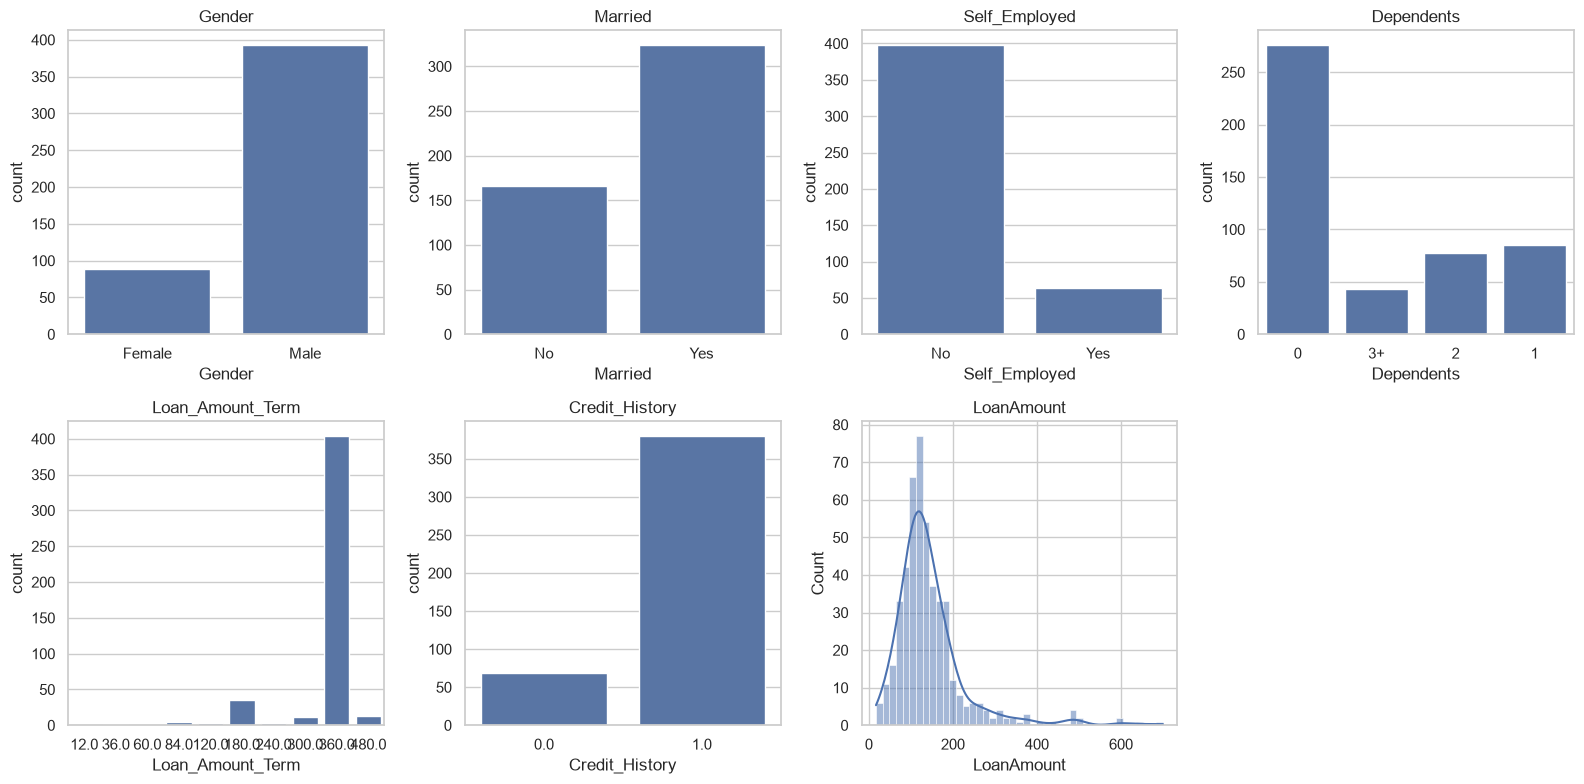

In [11]:
categorical_na_columns = ["Gender", "Married", "Self_Employed", "Dependents", "Loan_Amount_Term", "Credit_History"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, column in zip(axes, categorical_na_columns):
    sns.countplot(x=loan[column], ax=ax)
    ax.set_title(column)

sns.histplot(loan["LoanAmount"], kde=True, ax=axes[6])
axes[6].set_title("LoanAmount")

axes[7].axis("off")

plt.tight_layout()
plt.show()

In [12]:
loan["Loan_Amount_Term"].value_counts()

Loan_Amount_Term
360.0    404
180.0     35
480.0     13
300.0     12
84.0       4
240.0      3
120.0      3
36.0       2
12.0       1
60.0       1
Name: count, dtype: int64

In [13]:
clean_loan = loan.copy()

# Gender, Married, Self_Employed, Dependents, Loan_Amount_Term, Credit_History:
# faltantes de bajo volumen o sin relación aparente con el target -> imputar con la moda
categorical_impute_columns = ["Gender", "Married", "Self_Employed", "Dependents", "Loan_Amount_Term", "Credit_History"]
for column in categorical_impute_columns:
    mode = clean_loan[column].mode()[0]
    clean_loan[column] = clean_loan[column].fillna(mode)

# LoanAmount: numérica y sesgada -> la mediana es más robusta que la media para imputar
clean_loan["LoanAmount"] = clean_loan["LoanAmount"].fillna(clean_loan["LoanAmount"].median())

print(f"Valores faltantes restantes: {clean_loan.isna().sum().sum()}")

Valores faltantes restantes: 0


## 3. Feature engineering

Con los datos limpios, construimos dos variables derivadas que tienen sentido de negocio directo en evaluación de riesgo crediticio, cada una responde a una pregunta que las variables originales no responden solas:

- **`TotalIncome`**: la capacidad real de pago depende del ingreso del hogar, no solo del solicitante. Además, resuelve un caso que `ApplicantIncome` solo no captura: el 44% de los coaplicantes tiene `CoapplicantIncome == 0` (aplicación individual, sin ingreso adicional que sumar).
- **`LoanAmount_to_Income`**: la carga de deuda relativa al ingreso, el mismo tipo de métrica que usan las entidades de crédito para decidir aprobación, y potencialmente más informativa que el monto del préstamo o el ingreso por separado. **Nota de unidades:** según el diccionario de datos, `LoanAmount` está expresado en miles mientras que `ApplicantIncome`/`CoapplicantIncome` no, dividirlas directamente mezclaría escalas distintas. Por eso multiplicamos `LoanAmount` por 1000 antes de dividir, dejando el ratio en una escala interpretable: aproximadamente cuántos meses de ingreso representa el monto del préstamo.

In [14]:
clean_loan["TotalIncome"] = clean_loan["ApplicantIncome"] + clean_loan["CoapplicantIncome"]
# LoanAmount está en miles (ver diccionario de datos); se multiplica por 1000 para que quede
# en la misma escala que TotalIncome antes de dividir
clean_loan["LoanAmount_to_Income"] = (clean_loan["LoanAmount"] * 1000) / clean_loan["TotalIncome"]

clean_loan[["ApplicantIncome", "CoapplicantIncome", "TotalIncome", "LoanAmount", "LoanAmount_to_Income"]].head()

,ApplicantIncome,CoapplicantIncome,TotalIncome,LoanAmount,LoanAmount_to_Income
0,4547,0.0,4547.0,115.0,25.291
1,5703,0.0,5703.0,130.0,22.795
2,4333,2451.0,6784.0,110.0,16.215
3,4695,0.0,4695.0,96.0,20.447
4,6700,1750.0,8450.0,230.0,27.219


## 4. Descriptiva de variables cualitativas

Empezamos por las variables categóricas: `Gender`, `Married`, `Education` y `Property_Area`, relacionándolas con `Loan_Status` (nuestro target).

In [66]:
gender_table = clean_loan["Gender"].value_counts().to_frame(name="FA")
gender_table["FR"] = gender_table["FA"] / len(clean_loan)
gender_table["Porcentaje (%)"] = gender_table["FR"] * 100
gender_table

,FA,FR,Porcentaje (%)
Gender,,,
Male,403,0.821,82.077
Female,88,0.179,17.923


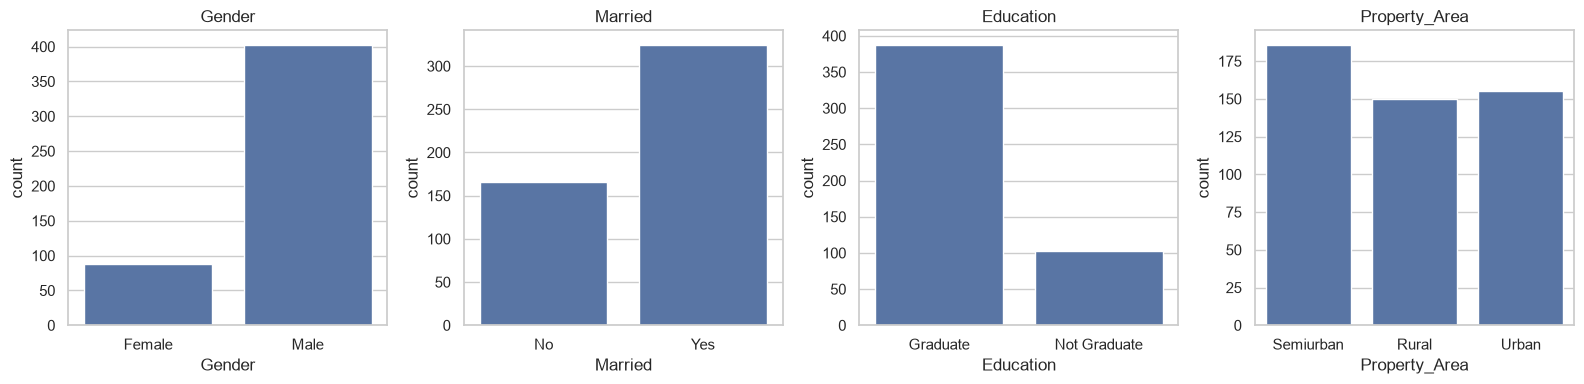

In [67]:
categorical_columns = ["Gender", "Married", "Education", "Property_Area"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, column in zip(axes, categorical_columns):
    sns.countplot(x=clean_loan[column], ax=ax)
    ax.set_title(column)
plt.tight_layout()
plt.show()

In [68]:
for column in ["Gender", "Married", "Education", "Property_Area"]:
    print(f"--- {column} x Loan_Status (normalizado por fila, %) ---")
    print((pd.crosstab(clean_loan[column], clean_loan["Loan_Status"], normalize="index") * 100).round(1))
    print()

--- Gender x Loan_Status (normalizado por fila, %) ---
Loan_Status     0     1
Gender                 
Female       37.5  62.5
Male         28.5  71.5

--- Married x Loan_Status (normalizado por fila, %) ---
Loan_Status     0     1
Married                
No           38.6  61.4
Yes          25.8  74.2

--- Education x Loan_Status (normalizado por fila, %) ---
Loan_Status      0     1
Education               
Graduate      28.4  71.6
Not Graduate  36.9  63.1

--- Property_Area x Loan_Status (normalizado por fila, %) ---
Loan_Status       0     1
Property_Area            
Rural          38.0  62.0
Semiurban      22.6  77.4
Urban          31.6  68.4



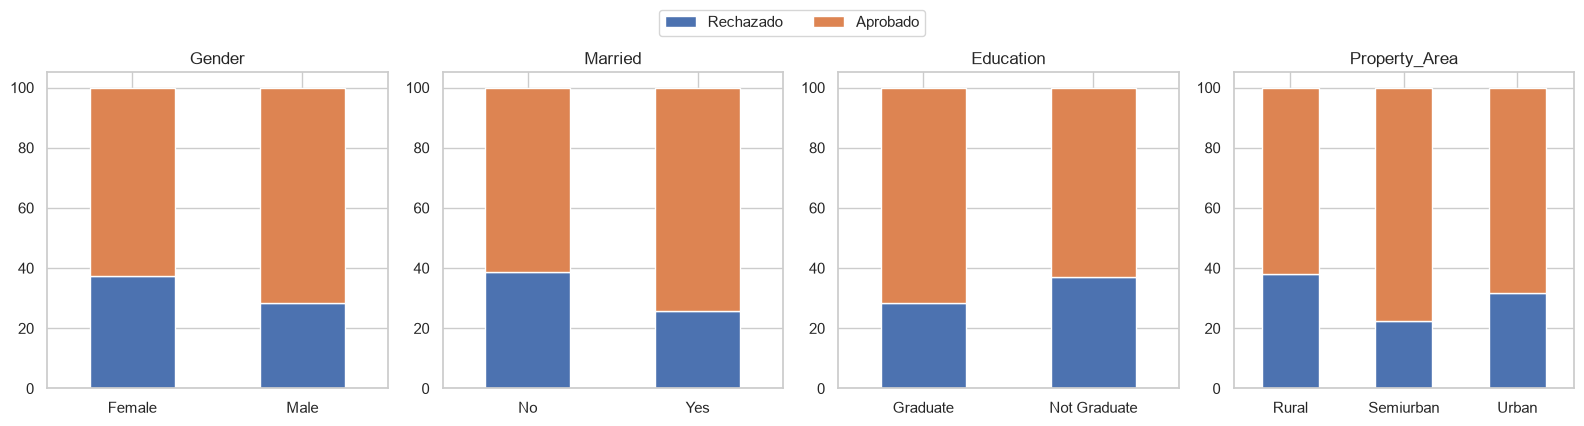

In [69]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, column in zip(axes, categorical_columns):
    composition = pd.crosstab(clean_loan[column], clean_loan["Loan_Status"], normalize="index") * 100
    composition.columns = ["Rechazado", "Aprobado"]
    composition.plot(kind="bar", stacked=True, ax=ax, legend=False)
    ax.set_title(column)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()

La tasa de aprobación general es ~69.9%. Por categoría: `Married == "Yes"` aprueba más (~74.1%) que `"No"` (~61.4%); `Property_Area == "Semiurban"` aprueba más (~77.4%) que `"Rural"` (~62.0%); `Education == "Graduate"` aprueba algo más (~71.6%) que `"Not Graduate"` (~63.1%); `Gender` muestra una diferencia menor (Male ~71.5% vs. Female ~62.5%, con solo 88 mujeres en la muestra). Ninguna de estas diferencias es enorme — son candidatas a revisar, no conclusiones.

## 5. Descriptiva de variables cuantitativas

Usamos `ApplicantIncome` como variable "hilo conductor" de esta sección (igual que `horsepower` en las sesiones 2 y 3).

In [19]:
clean_loan["ApplicantIncome"].describe()

count      491.000
mean      5401.189
std       6419.427
min        150.000
25%       2923.500
50%       3865.000
75%       5705.500
max      81000.000
Name: ApplicantIncome, dtype: float64

In [20]:
income = clean_loan["ApplicantIncome"]

mean_income = income.mean()
median_income = income.median()
std_income = income.std(ddof=1)
cv_income = std_income / mean_income * 100
q1, q3 = income.quantile([0.25, 0.75])
iqr = q3 - q1

print(f"Media: {mean_income:.0f}")
print(f"Mediana: {median_income:.0f}")
print(f"Desviación estándar: {std_income:.0f}")
print(f"Coeficiente de variación: {cv_income:.1f}%")
print(f"Q1: {q1:.0f}, Q3: {q3:.0f}, IQR: {iqr:.0f}")

Media: 5401
Mediana: 3865
Desviación estándar: 6419
Coeficiente de variación: 118.9%
Q1: 2924, Q3: 5706, IQR: 2782


La media (~5,401) es mucho mayor que la mediana (~3,865) y el coeficiente de variación es altísimo (~119%): un primer indicio de una asimetría a la derecha muy marcada.

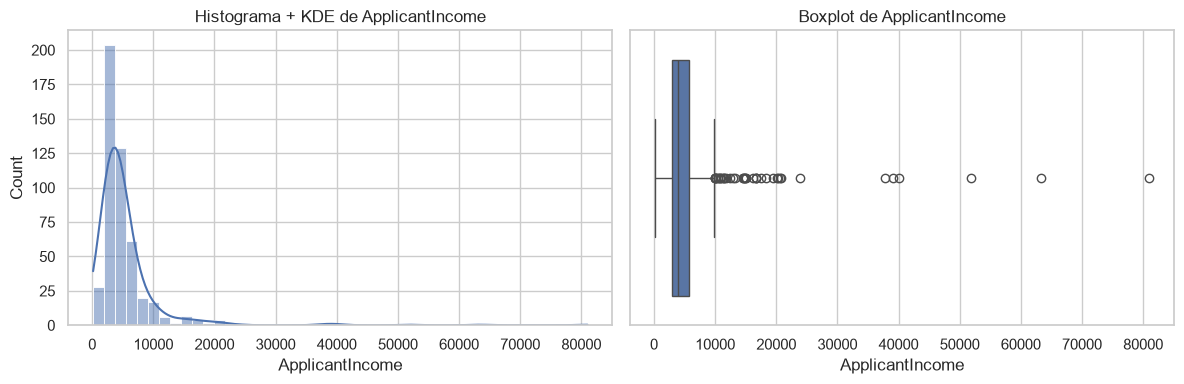

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(income, kde=True, ax=axes[0])
axes[0].set_title("Histograma + KDE de ApplicantIncome")
sns.boxplot(x=income, ax=axes[1])
axes[1].set_title("Boxplot de ApplicantIncome")
plt.tight_layout()
plt.show()

### Evaluación de normalidad de `ApplicantIncome`

Asimetría: 6.76
Curtosis (exceso): 60.74
Shapiro-Wilk p-valor: 1.82e-36


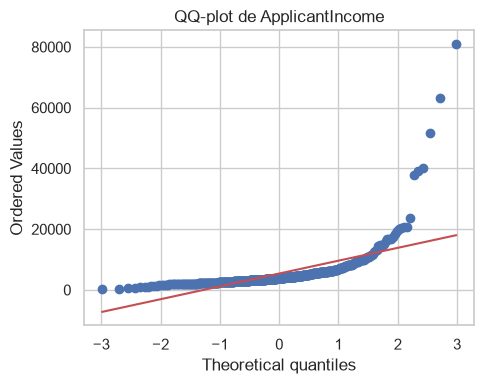

In [22]:
income_skew = stats.skew(income)
income_kurtosis = stats.kurtosis(income)
_, income_p_value = stats.shapiro(income)

print(f"Asimetría: {income_skew:.2f}")
print(f"Curtosis (exceso): {income_kurtosis:.2f}")
print(f"Shapiro-Wilk p-valor: {income_p_value:.2e}")

fig, ax = plt.subplots(figsize=(5, 4))
stats.probplot(income, dist="norm", plot=ax)
ax.set_title("QQ-plot de ApplicantIncome")
plt.tight_layout()
plt.show()

Una asimetría de ~6.8 es extrema — muy por encima de lo visto con `horsepower` (~1.1) en la sesión 3 — y la curtosis (~61) confirma colas mucho más pesadas que una normal. Shapiro-Wilk rechaza normalidad con un p-valor prácticamente nulo. El QQ-plot muestra un puñado de puntos muy alejados de la línea de normalidad en la cola superior: unos pocos solicitantes con ingresos extremadamente altos frente al resto.

## 6. Tratamiento de atípicos

Hasta ahora solo detectamos atípicos (regla del IQR, como en sesiones anteriores). Aquí vamos un paso más allá: **¿qué hacer con ellos?** Eliminarlos no es defendible — son solicitantes reales con ingresos altos, y borrarlos sesgaría la muestra hacia ingresos bajos, justo cuando el objetivo es describir a todos los solicitantes por igual.

In [23]:
for column in ["ApplicantIncome", "LoanAmount"]:
    series = clean_loan[column]
    q1_c, q3_c = series.quantile([0.25, 0.75])
    iqr_c = q3_c - q1_c
    upper_limit = q3_c + 1.5 * iqr_c
    n_outliers = (series > upper_limit).sum()
    print(f"{column}: límite superior = {upper_limit:.0f}, atípicos = {n_outliers} ({n_outliers / len(series):.1%}), máximo = {series.max():.0f}")

ApplicantIncome: límite superior = 9878, atípicos = 41 (8.4%), máximo = 81000
LoanAmount: límite superior = 250, atípicos = 40 (8.1%), máximo = 700


`ApplicantIncome` tiene 41 atípicos (8.4%, máximo 81,000 frente a un límite de ~9,879) y `LoanAmount` tiene 40 (8.1%, máximo 700 frente a un límite de 250). Volúmenes demasiado grandes para ignorar, y demasiado reales para eliminar.

In [24]:
q1_income, q3_income = income.quantile([0.25, 0.75])
upper_income = q3_income + 1.5 * (q3_income - q1_income)

q1_loan, q3_loan = clean_loan["LoanAmount"].quantile([0.25, 0.75])
upper_loan = q3_loan + 1.5 * (q3_loan - q1_loan)

# Capping/winsorizing: recorta al límite superior del IQR, conserva la fila y las unidades originales
clean_loan["ApplicantIncome_capped"] = income.clip(upper=upper_income)
clean_loan["LoanAmount_capped"] = clean_loan["LoanAmount"].clip(upper=upper_loan)

# Alternativa: transformación logarítmica (ya vista en sesión 3)
income_log = np.log1p(income)

print(f"Asimetría original: {stats.skew(income):.2f}")
print(f"Asimetría con capping: {stats.skew(clean_loan['ApplicantIncome_capped']):.2f}")
print(f"Asimetría con log: {stats.skew(income_log):.2f}")

Asimetría original: 6.76
Asimetría con capping: 1.00
Asimetría con log: 0.59


El capping reduce la asimetría de ~6.8 a ~1.0 — mejora notable, pero está lejos de la simetría. El log-transform la baja a ~0.6, más cerca de una distribución simétrica. La diferencia tiene una razón: el capping solo recorta los valores extremos, mientras que el log comprime toda la escala. La elección depende del objetivo: **capping** si se necesita seguir interpretando la variable en sus unidades originales (dólares) para reportes o comparaciones directas; **log-transform** si el objetivo es una distribución más simétrica para un análisis o modelo posterior, aceptando que la escala deja de ser directamente interpretable. En este taller usamos la versión con capping para las comparaciones de la siguiente sección, porque seguimos hablando en términos de ingreso real.

## 7. Relación con la variable target (`Loan_Status`)

Cerramos comparando las variables numéricas (incluyendo las tratadas y las derivadas) frente al estado de aprobación.

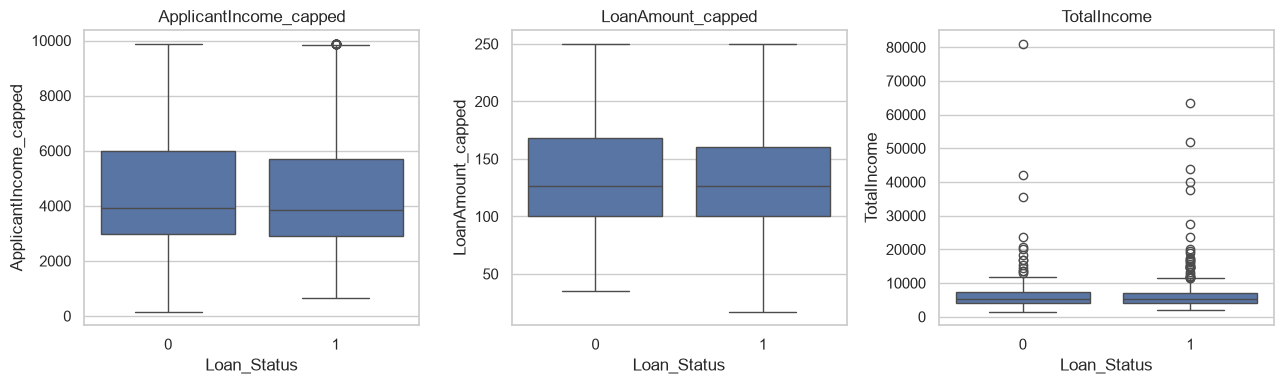

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, column in zip(axes, ["ApplicantIncome_capped", "LoanAmount_capped", "TotalIncome"]):
    sns.boxplot(data=clean_loan, x="Loan_Status", y=column, ax=ax)
    ax.set_title(column)
plt.tight_layout()
plt.show()

In [26]:
clean_loan.groupby("Loan_Status")[["ApplicantIncome_capped", "LoanAmount_capped", "TotalIncome", "LoanAmount_to_Income"]].agg(["mean", "median"])

ApplicantIncome_capped         LoanAmount_capped         \
                              mean  median              mean median   
Loan_Status                                                           
0                         4609.226  3911.5           137.176  126.0   
1                         4542.192  3859.0           133.854  126.0   

            TotalIncome         LoanAmount_to_Income          
                   mean  median                 mean  median  
Loan_Status                                                   
0              7228.676  5177.0               25.215  23.670  
1              6888.332  5391.0               23.237  24.114

**El hallazgo más contraintuitivo del taller:** `ApplicantIncome`, `LoanAmount`, `TotalIncome` y `LoanAmount_to_Income` apenas difieren entre aprobados y rechazados (medias y medianas muy cercanas entre los dos grupos — la carga de deuda, por ejemplo, es ~23.2 meses de ingreso en aprobados frente a ~25.2 en rechazados, una diferencia pequeña). Uno esperaría que un ingreso más alto o una carga de deuda menor facilite la aprobación, pero estos datos no lo muestran con fuerza — ni siquiera con la variable que construimos específicamente para capturar esa relación. No se puede concluir que el ingreso no importe en la realidad, solo que en este dataset no es la señal dominante que distingue aprobados de rechazados.

In [27]:
(pd.crosstab(clean_loan["Credit_History"], clean_loan["Loan_Status"], normalize="index") * 100).round(1)

Loan_Status,0,1
Credit_History,,
0.0,91.2,8.8
1.0,20.3,79.7


`Credit_History` sí marca una diferencia enorme: ~79.7% de aprobación cuando vale 1, frente a ~8.8% cuando vale 0 — una brecha de más de 70 puntos porcentuales, muchísimo mayor que cualquier diferencia vista con las variables cualitativas o cuantitativas anteriores. Es, con diferencia, la variable más asociada a `Loan_Status` en todo el dataset.

## Cierre

**Ideas clave:**

- La limpieza de datos no siempre implica eliminar filas: aquí todos los faltantes se resolvieron con imputación, pero la decisión de *cómo* imputar (moda, mediana, o verificar primero si la ausencia se relaciona con el target) sí varió por variable.
- Antes de imputar una variable con muchos faltantes, vale la pena revisar si esos faltantes se comportan distinto al resto respecto al target — `Credit_History` mostró que no era el caso, lo que justificó una imputación simple.
- Una variable derivada (`TotalIncome`, `LoanAmount_to_Income`) solo aporta si responde una pregunta que las originales no responden — aquí tenían sentido de negocio claro, aunque terminaron sin mostrar relación fuerte con el target.
- Detectar atípicos con IQR es solo el primer paso; tratarlos (capping vs. transformación log) es una decisión con trade-offs distintos según si necesitas conservar las unidades originales o priorizar simetría.
- El hallazgo más importante no fue el esperado: el ingreso (y las variables derivadas de él) casi no diferencia aprobados de rechazados, mientras que `Credit_History` domina por completo — un recordatorio de que la intuición de negocio hay que contrastarla con los datos, no asumirla.

**Qué queda fuera a propósito:** este taller se queda en estadística *descriptiva*. No se prueba si estas diferencias son estadísticamente significativas (eso requiere pruebas de hipótesis) ni se construye ningún modelo de clasificación — eso es contenido de la sesión 6 en adelante.